# **Crowd Risk & Anomaly Detection Training Notebook**

This notebook trains and evaluates crowd anomaly detection models using the same video-level split, filtering, and feature pipeline used by the realtime demo. Multiple ML classifiers are compared, while the final saved model package remains compatible with `demo.py`.


## 1. Imports & Configuration

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# -----------------------------
# Paths
# -----------------------------
DATASET_PATH = Path("../output/ml_dataset.csv")
MODEL_SAVE_PATH = Path("../output/random_forest_model_v2.pkl")
EVAL_DIR = Path("output/evaluation")

# -----------------------------
# Experiment settings
# -----------------------------
TEST_VIDEOS = ["umn13", "umn14", "umn15", "umn16"]
RANDOM_STATE = 42

# Keep this switch so you can compare full dataset vs filtered dataset.
FILTER_EMPTY_NORMAL_CELLS = True

# Keep True when you want a model comparison table for the report.
# This does not change the final saved Random Forest model used by demo.py.
RUN_MODEL_COMPARISON = True


## 2. Load Dataset

In [2]:
print("Dataset path:", DATASET_PATH)

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH.resolve()}")

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset path: ..\output\ml_dataset.csv
Dataset shape: (118375, 20)


,video_name,frame,cell_x,cell_y,density,avg_velocity,avg_acc,congestion,turbulence,flow_conflict,avg_track_risk,density_n,dispersion_n,congestion_n,turbulence_n,flow_conflict_n,velocity_n,acc_n,track_risk_n,label
0,umn1,4,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.4,0.0,0
1,umn1,5,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.4,0.0,0
2,umn1,6,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.4,0.0,0
3,umn1,7,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.4,0.0,0
4,umn1,8,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.4,0.0,0


## 3. Dataset Inspection

Dataset inspection is for basic sanity checks: columns, row count, labels, videos, data types, missing values, and empty-cell percentage.


### 3.1 Basic Dataset Checks

In [3]:
print("Columns:")
print(df.columns.tolist())

print("Total rows:", len(df))

print("Label counts:")
print(df["label"].value_counts())

print("Label percentage:")
print(df["label"].value_counts(normalize=True) * 100)

print("Video counts:")
print(df["video_name"].value_counts().sort_index())


Columns:
['video_name', 'frame', 'cell_x', 'cell_y', 'density', 'avg_velocity', 'avg_acc', 'congestion', 'turbulence', 'flow_conflict', 'avg_track_risk', 'density_n', 'dispersion_n', 'congestion_n', 'turbulence_n', 'flow_conflict_n', 'velocity_n', 'acc_n', 'track_risk_n', 'label']
Total rows: 118375
Label counts:
label
0    103000
1     15375
Name: count, dtype: int64
Label percentage:
label
0    87.011616
1    12.988384
Name: proportion, dtype: float64
Video counts:
video_name
umn1     7750
umn10    7525
umn11    8050
umn12    8475
umn13    7575
umn14    6675
umn15    7600
umn16    7850
umn2     7350
umn3     7600
umn4     7625
umn5     7550
umn6     4750
umn7     7475
umn8     7050
umn9     7475
Name: count, dtype: int64


### 3.2 Missing Values and Data Types

In [4]:
print("Data types:")
print(df.dtypes)

missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

print("Total missing values:", missing_values.sum())


Data types:
video_name             str
frame                int64
cell_x               int64
cell_y               int64
density              int64
avg_velocity       float64
avg_acc            float64
congestion         float64
turbulence         float64
flow_conflict      float64
avg_track_risk     float64
density_n          float64
dispersion_n       float64
congestion_n       float64
turbulence_n       float64
flow_conflict_n    float64
velocity_n         float64
acc_n              float64
track_risk_n       float64
label                int64
dtype: object
Missing values per column:
Series([], dtype: int64)
Total missing values: 0


### 3.3 Empty Cell Analysis

In [5]:
empty_cell_percentage = (df["density"] == 0).mean() * 100
active_cell_percentage = (df["density"] > 0).mean() * 100

print(f"Empty-cell percentage : {empty_cell_percentage:.2f}%")
print(f"Active-cell percentage: {active_cell_percentage:.2f}%")

print("Empty cells by label:")
print(pd.crosstab(df["label"], df["density"] == 0, rownames=["label"], colnames=["is_empty_cell"]))


Empty-cell percentage : 67.56%
Active-cell percentage: 32.44%
Empty cells by label:
is_empty_cell  False  True 
label                      
0              35076  67924
1               3322  12053


## 4. Exploratory Data Analysis (EDA)

EDA is for understanding patterns in the dataset before modifying it. These plots help explain class imbalance, grid sparsity, feature behavior, correlations, and video-wise anomaly distribution.


### 4.1 Class Distribution

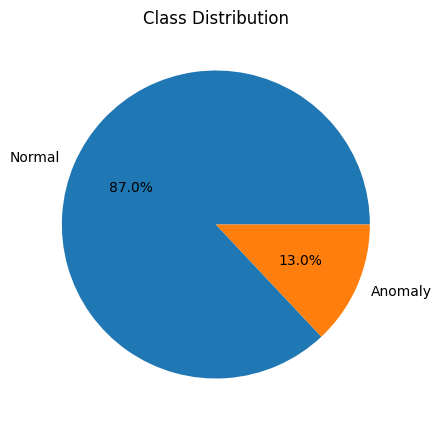

label
0    103000
1     15375
Name: count, dtype: int64

In [6]:
label_counts = df["label"].value_counts().sort_index()
label_names = ["Normal", "Anomaly"]

plt.figure(figsize=(5, 5))
plt.pie(label_counts, labels=label_names, autopct="%1.1f%%")
plt.title("Class Distribution")
plt.show()

label_counts


### 4.2 Grid Cell Activity Distribution

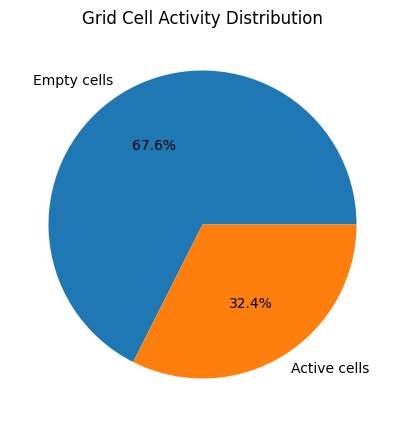

Empty cells     79977
Active cells    38398
dtype: int64

In [7]:
activity_counts = pd.Series({
    "Empty cells": (df["density"] == 0).sum(),
    "Active cells": (df["density"] > 0).sum(),
})

plt.figure(figsize=(5, 5))
plt.pie(activity_counts, labels=activity_counts.index, autopct="%1.1f%%")
plt.title("Grid Cell Activity Distribution")
plt.show()

activity_counts


### 4.3 Feature Summary Statistics

In [8]:
NUMERIC_COLUMNS = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude identifiers/label from feature-style statistics.
EDA_FEATURES = [
    col for col in NUMERIC_COLUMNS
    if col not in ["frame", "label"]
]

df[EDA_FEATURES].describe().T


,count,mean,std,min,25%,50%,75%,max
cell_x,118375.0,2.000000,1.414220,0.000000,1.00,2.0,3.000000,4.000000
cell_y,118375.0,2.000000,1.414220,0.000000,1.00,2.0,3.000000,4.000000
density,118375.0,0.653550,1.186827,0.000000,0.00,0.0,1.000000,12.000000
avg_velocity,118375.0,0.873600,2.564152,0.000000,0.00,0.0,0.804044,138.497396
avg_acc,118375.0,0.008169,1.601698,-50.660554,0.00,0.0,0.000000,129.381907
congestion,118375.0,18.543035,941.641404,0.000000,0.00,0.0,0.459195,50000.000000
turbulence,118375.0,1.207711,17.946630,0.000000,0.00,0.0,0.000000,2225.807297
flow_conflict,118375.0,0.107312,0.236305,0.000000,0.00,0.0,0.000000,0.916667
avg_track_risk,118375.0,0.050079,0.106457,0.000000,0.00,0.0,0.066462,0.999440
density_n,118375.0,0.032677,0.059341,0.000000,0.00,0.0,0.050000,0.600000


### 4.4 Feature Distribution by Label

Use this cell to quickly compare how one feature behaves for normal vs anomaly rows. Change `FEATURE_TO_PLOT` as needed.


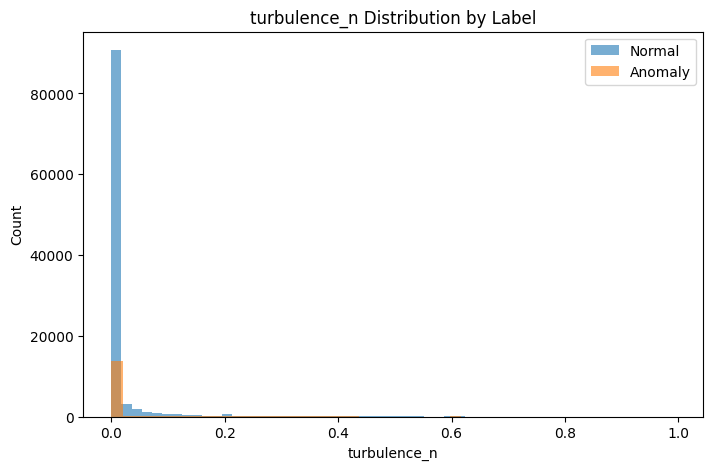

In [9]:
FEATURE_TO_PLOT = "turbulence_n"

plt.figure(figsize=(8, 5))

plt.hist(
    df[df["label"] == 0][FEATURE_TO_PLOT],
    bins=50,
    alpha=0.6,
    label="Normal",
)

plt.hist(
    df[df["label"] == 1][FEATURE_TO_PLOT],
    bins=50,
    alpha=0.6,
    label="Anomaly",
)

plt.legend()
plt.title(f"{FEATURE_TO_PLOT} Distribution by Label")
plt.xlabel(FEATURE_TO_PLOT)
plt.ylabel("Count")
plt.show()


### 4.5 Boxplots for Key Risk Features

<Figure size 600x400 with 0 Axes>

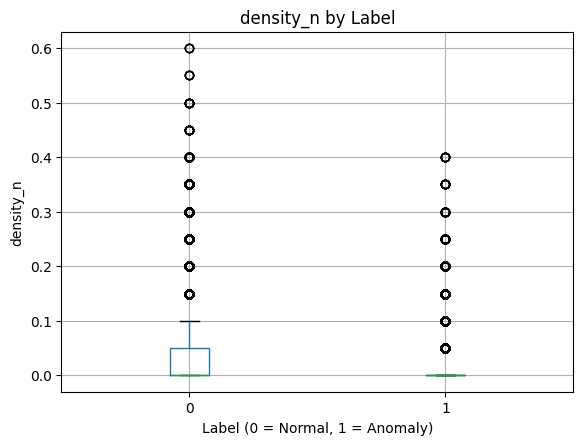

<Figure size 600x400 with 0 Axes>

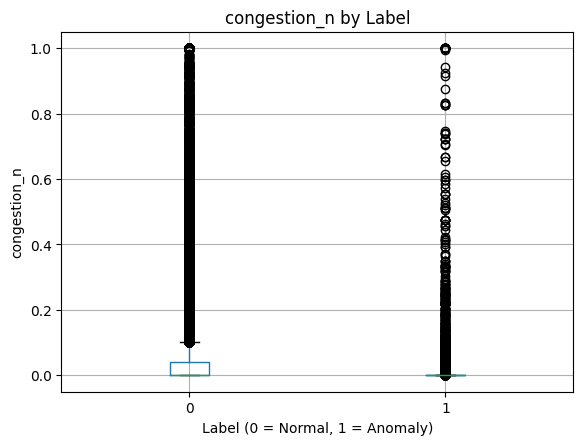

<Figure size 600x400 with 0 Axes>

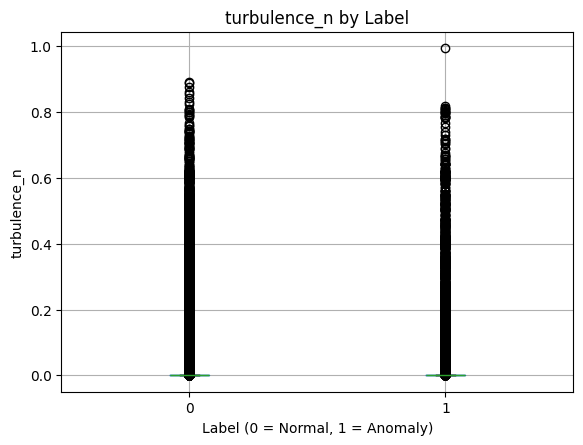

<Figure size 600x400 with 0 Axes>

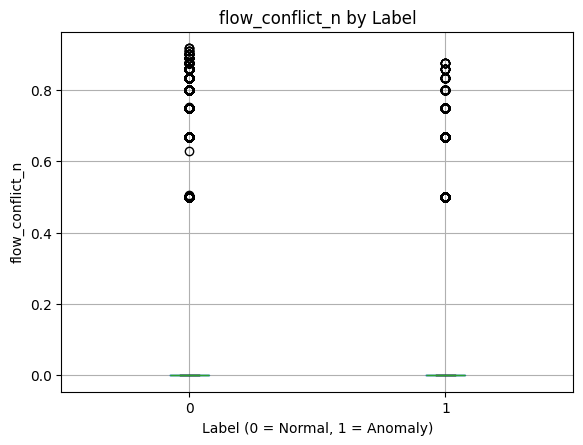

<Figure size 600x400 with 0 Axes>

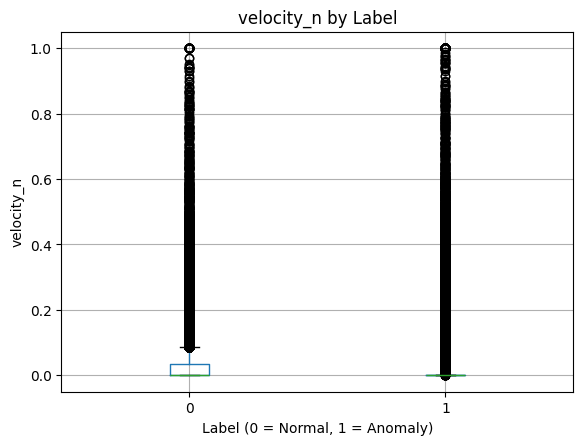

<Figure size 600x400 with 0 Axes>

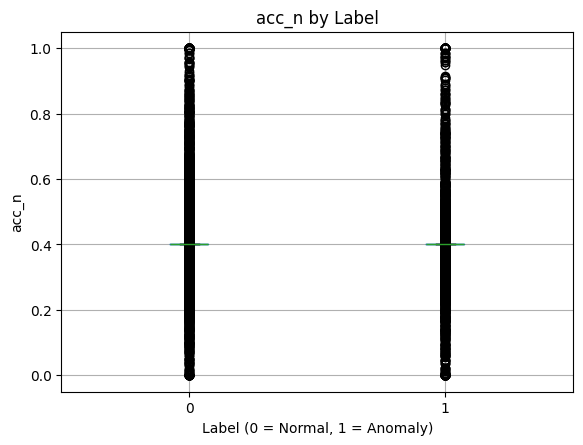

<Figure size 600x400 with 0 Axes>

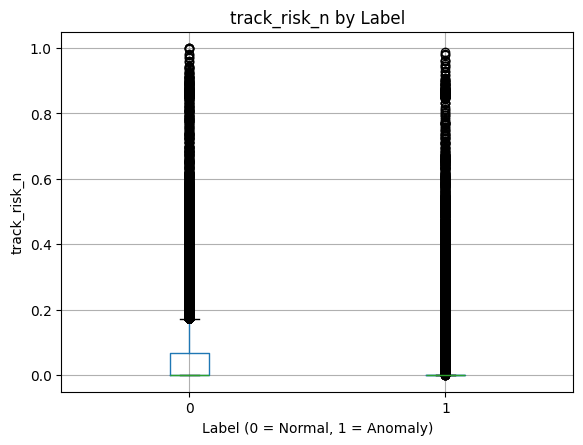

In [10]:
KEY_EDA_FEATURES = [
    "density_n",
    "congestion_n",
    "turbulence_n",
    "flow_conflict_n",
    "velocity_n",
    "acc_n",
    "track_risk_n",
]

for feature in KEY_EDA_FEATURES:
    if feature not in df.columns:
        continue

    plt.figure(figsize=(6, 4))
    df.boxplot(column=feature, by="label")
    plt.title(f"{feature} by Label")
    plt.suptitle("")
    plt.xlabel("Label (0 = Normal, 1 = Anomaly)")
    plt.ylabel(feature)
    plt.show()


### 4.6 Correlation Heatmap

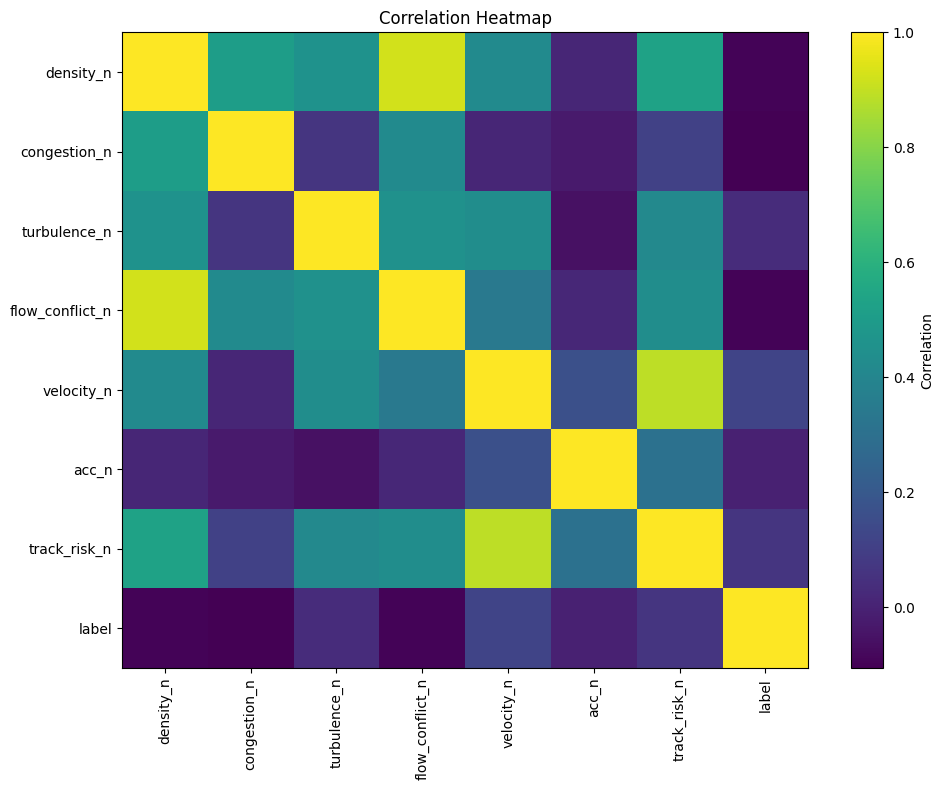

,density_n,congestion_n,turbulence_n,flow_conflict_n,velocity_n,acc_n,track_risk_n,label
density_n,1.000000,0.510204,0.456279,0.923676,0.421899,0.011395,0.531317,-0.095350
congestion_n,0.510204,1.000000,0.066542,0.425281,0.014180,-0.027230,0.109591,-0.105903
turbulence_n,0.456279,0.066542,1.000000,0.453014,0.434106,-0.056485,0.415243,0.032918
flow_conflict_n,0.923676,0.425281,0.453014,1.000000,0.339232,0.019074,0.434803,-0.093252
velocity_n,0.421899,0.014180,0.434106,0.339232,1.000000,0.164072,0.891416,0.121116
acc_n,0.011395,-0.027230,-0.056485,0.019074,0.164072,1.000000,0.306998,-0.002510
track_risk_n,0.531317,0.109591,0.415243,0.434803,0.891416,0.306998,1.000000,0.066358
label,-0.095350,-0.105903,0.032918,-0.093252,0.121116,-0.002510,0.066358,1.000000


In [11]:
corr_columns = [col for col in KEY_EDA_FEATURES if col in df.columns] + ["label"]
corr = df[corr_columns].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

corr


### 4.7 Anomaly Ratio per Video

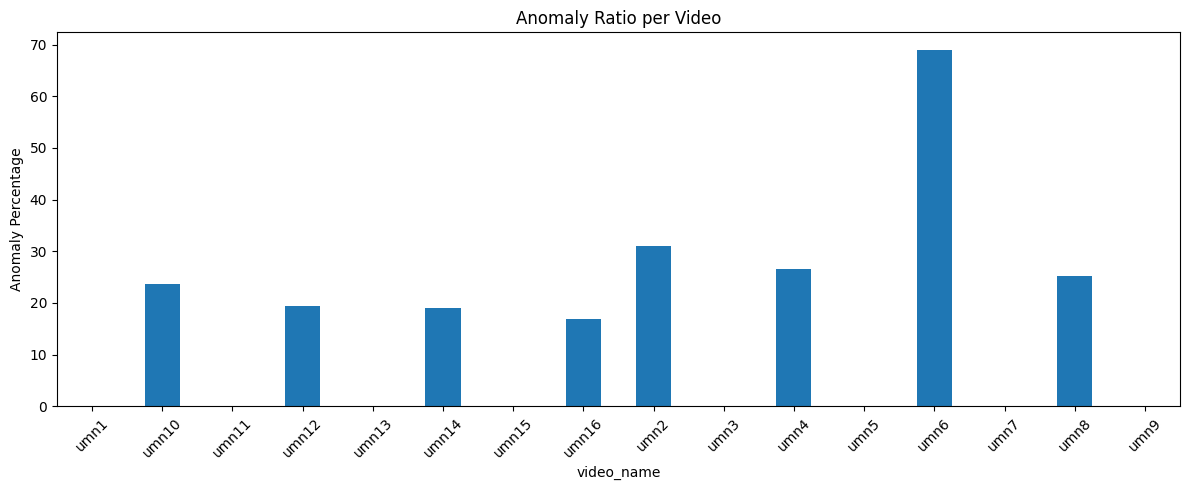

video_name
umn1      0.000000
umn10    23.588040
umn11     0.000000
umn12    19.469027
umn13     0.000000
umn14    19.101124
umn15     0.000000
umn16    16.878981
umn2     30.952381
umn3      0.000000
umn4     26.557377
umn5      0.000000
umn6     68.947368
umn7      0.000000
umn8     25.177305
umn9      0.000000
Name: label, dtype: float64

In [12]:
video_anomaly_ratio = (df.groupby("video_name")["label"].mean() * 100).sort_index()

plt.figure(figsize=(12, 5))
video_anomaly_ratio.plot(kind="bar")
plt.ylabel("Anomaly Percentage")
plt.title("Anomaly Ratio per Video")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

video_anomaly_ratio


### 4.8 Temporal Risk Trend for One Video

This helps visualize whether risk features rise around anomaly frames. Change `VIDEO_TO_PLOT` to inspect other videos.


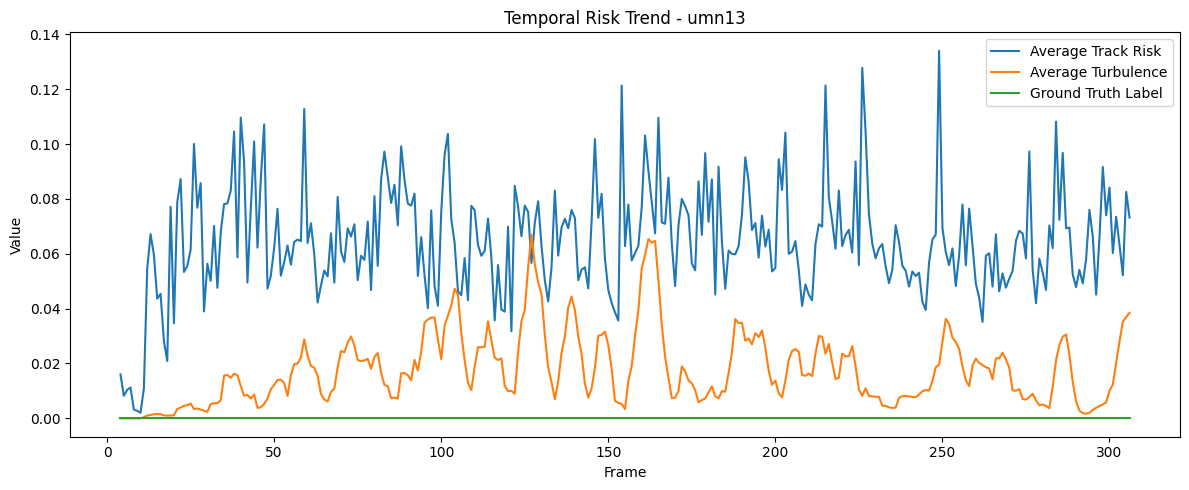

In [13]:
VIDEO_TO_PLOT = "umn13"

vdf = df[df["video_name"] == VIDEO_TO_PLOT]

if len(vdf) == 0:
    print(f"Video not found: {VIDEO_TO_PLOT}")
else:
    frame_summary = vdf.groupby("frame").agg(
        avg_track_risk=("avg_track_risk", "mean"),
        turbulence_n=("turbulence_n", "mean"),
        label=("label", "max"),
    )

    plt.figure(figsize=(12, 5))
    plt.plot(frame_summary.index, frame_summary["avg_track_risk"], label="Average Track Risk")
    plt.plot(frame_summary.index, frame_summary["turbulence_n"], label="Average Turbulence")
    plt.plot(frame_summary.index, frame_summary["label"], label="Ground Truth Label")
    plt.title(f"Temporal Risk Trend - {VIDEO_TO_PLOT}")
    plt.xlabel("Frame")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

    frame_summary.head()


## 5. Optional Preprocessing / Filtering

This is intentionally placed after raw-data EDA. The switch `FILTER_EMPTY_NORMAL_CELLS` lets you compare full-dataset training against filtered training.

Filtering removes only empty normal cells:

`label == 0 and density == 0`

It keeps all anomaly rows and all normal rows with people present.


In [14]:
df_raw = df.copy()

if FILTER_EMPTY_NORMAL_CELLS:
    before_rows = len(df)
    df = df[(df["label"] == 1) | (df["density"] > 0)].copy()
    after_rows = len(df)

    print("Applied empty-normal-cell filtering")
    print(f"Rows before filtering: {before_rows}")
    print(f"Rows after filtering : {after_rows}")
    print(f"Rows removed         : {before_rows - after_rows}")
else:
    print("No empty-cell filtering applied")

print("Label percentage after preprocessing:")
print(df["label"].value_counts(normalize=True) * 100)


Applied empty-normal-cell filtering
Rows before filtering: 118375
Rows after filtering : 50451
Rows removed         : 67924
Label percentage after preprocessing:
label
0    69.524886
1    30.475114
Name: proportion, dtype: float64


## 6. Feature Selection

In [15]:
FEATURES = [
    "cell_x",
    "cell_y",
    "density",
    "avg_velocity",
    "avg_acc",
    "congestion",
    "turbulence",
    "flow_conflict",
    "avg_track_risk",
    "density_n",
    "congestion_n",
    "turbulence_n",
    "flow_conflict_n",
    "velocity_n",
    "acc_n",
    "track_risk_n",
]

if "dispersion_n" in df.columns:
    FEATURES.append("dispersion_n")

missing_features = [feature for feature in FEATURES if feature not in df.columns]
if missing_features:
    raise ValueError(f"Missing features in dataset: {missing_features}")

df = df.dropna(subset=FEATURES + ["label", "video_name"])
df["label"] = df["label"].astype(int)

print("Features used:")
for feature in FEATURES:
    print("-", feature)


Features used:
- cell_x
- cell_y
- density
- avg_velocity
- avg_acc
- congestion
- turbulence
- flow_conflict
- avg_track_risk
- density_n
- congestion_n
- turbulence_n
- flow_conflict_n
- velocity_n
- acc_n
- track_risk_n
- dispersion_n


## 7. Train/Test Split by Video

Splitting by video is important because row-wise random splitting would leak visually similar frames from the same video into both train and test sets.


In [16]:
train_df = df[~df["video_name"].isin(TEST_VIDEOS)].copy()
test_df = df[df["video_name"].isin(TEST_VIDEOS)].copy()

if len(test_df) == 0:
    raise ValueError("Test dataframe is empty. Check TEST_VIDEOS names.")

X_train = train_df[FEATURES]
y_train = train_df["label"]

X_test = test_df[FEATURES]
y_test = test_df["label"]

print("Train videos:", sorted(train_df["video_name"].unique()))
print("Test videos :", sorted(test_df["video_name"].unique()))

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

print("Train label balance:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("Test label balance:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)


Train videos: ['umn1', 'umn10', 'umn11', 'umn12', 'umn2', 'umn3', 'umn4', 'umn5', 'umn6', 'umn7', 'umn8', 'umn9']
Test videos : ['umn13', 'umn14', 'umn15', 'umn16']
Train rows: 36584
Test rows : 13867
Train label balance:
label
0    23809
1    12775
Name: count, dtype: int64
label
0    65.080363
1    34.919637
Name: proportion, dtype: float64
Test label balance:
label
0    11267
1     2600
Name: count, dtype: int64
label
0    81.250451
1    18.749549
Name: proportion, dtype: float64


## 8. Model Comparison

This section compares multiple classical ML models using the same train/test split and selected features. The final production/demo model is still trained and saved in the next section as Random Forest to preserve compatibility with the realtime demo pipeline.


In [17]:
comparison_results = []
trained_comparison_models = {}

if RUN_MODEL_COMPARISON:
    comparison_models = {
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            )
        ),

        "Decision Tree": DecisionTreeClassifier(
            max_depth=12,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            max_depth=14,
            min_samples_split=10,
            min_samples_leaf=4,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "Extra Trees": ExtraTreesClassifier(
            n_estimators=500,
            max_depth=14,
            min_samples_split=10,
            min_samples_leaf=4,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=RANDOM_STATE,
        ),
    }

    for name, clf in comparison_models.items():
        print(f"Training {name}...")
        clf.fit(X_train, y_train)
        trained_comparison_models[name] = clf

        if hasattr(clf, "predict_proba"):
            y_prob_cmp = clf.predict_proba(X_test)[:, 1]
            y_pred_default_cmp = (y_prob_cmp >= 0.50).astype(int)

            # Also compute best F1 threshold for comparison only.
            best_f1 = -1
            best_threshold = 0.50
            best_pred = y_pred_default_cmp

            for threshold in np.arange(0.10, 0.91, 0.05):
                y_pred_t = (y_prob_cmp >= threshold).astype(int)
                f1_t = f1_score(y_test, y_pred_t, zero_division=0)

                if f1_t > best_f1:
                    best_f1 = f1_t
                    best_threshold = threshold
                    best_pred = y_pred_t
        else:
            y_pred_default_cmp = clf.predict(X_test)
            best_threshold = None
            best_pred = y_pred_default_cmp

        comparison_results.append({
            "model": name,
            "accuracy_default_0.50": accuracy_score(y_test, y_pred_default_cmp),
            "precision_default_0.50": precision_score(y_test, y_pred_default_cmp, zero_division=0),
            "recall_default_0.50": recall_score(y_test, y_pred_default_cmp, zero_division=0),
            "f1_default_0.50": f1_score(y_test, y_pred_default_cmp, zero_division=0),
            "best_threshold": best_threshold,
            "accuracy_best_threshold": accuracy_score(y_test, best_pred),
            "precision_best_threshold": precision_score(y_test, best_pred, zero_division=0),
            "recall_best_threshold": recall_score(y_test, best_pred, zero_division=0),
            "f1_best_threshold": f1_score(y_test, best_pred, zero_division=0),
        })

    comparison_df = (
        pd.DataFrame(comparison_results)
        .sort_values("f1_best_threshold", ascending=False)
        .reset_index(drop=True)
    )

    comparison_df
else:
    comparison_df = pd.DataFrame()
    print("Model comparison skipped because RUN_MODEL_COMPARISON = False")


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...


### 8.1 Model Comparison Plot


In [19]:
# Model comparison table + plots

if RUN_MODEL_COMPARISON and not comparison_df.empty:
    
    # Select useful columns
    display_cols = [
        "model",
        "accuracy_default",
        "precision_default",
        "recall_default",
        "f1_default",
        "best_threshold",
        "accuracy_best_threshold",
        "precision_best_threshold",
        "recall_best_threshold",
        "f1_best_threshold",
    ]

    # Keep only columns that exist
    display_cols = [col for col in display_cols if col in comparison_df.columns]

    results_display = comparison_df[display_cols].copy()

    # Sort by best F1-score
    results_display = results_display.sort_values(
        "f1_best_threshold",
        ascending=False
    )

    # Round numeric columns
    numeric_cols = results_display.select_dtypes(include=["float64", "float32"]).columns
    results_display[numeric_cols] = results_display[numeric_cols].round(4)

    print("Model Comparison Results:")
    display(results_display)

    # Save table
    results_display.to_csv(
        "output/evaluation/model_comparison_results_display.csv",
        index=False
    )

    print("\nSaved table to:")
    print("output/evaluation/model_comparison_results_display.csv")

else:
    print("No model comparison results to display.")

Model Comparison Results:


,model,best_threshold,accuracy_best_threshold,precision_best_threshold,recall_best_threshold,f1_best_threshold
0,Extra Trees,0.75,0.9621,0.9684,0.8250,0.8910
1,Gradient Boosting,0.80,0.9622,0.9806,0.8146,0.8899
2,Random Forest,0.85,0.9614,0.9814,0.8096,0.8872
3,Logistic Regression,0.90,0.9561,0.9535,0.8050,0.8730
4,Decision Tree,0.90,0.9445,0.8617,0.8388,0.8501



Saved table to:
output/evaluation/model_comparison_results_display.csv


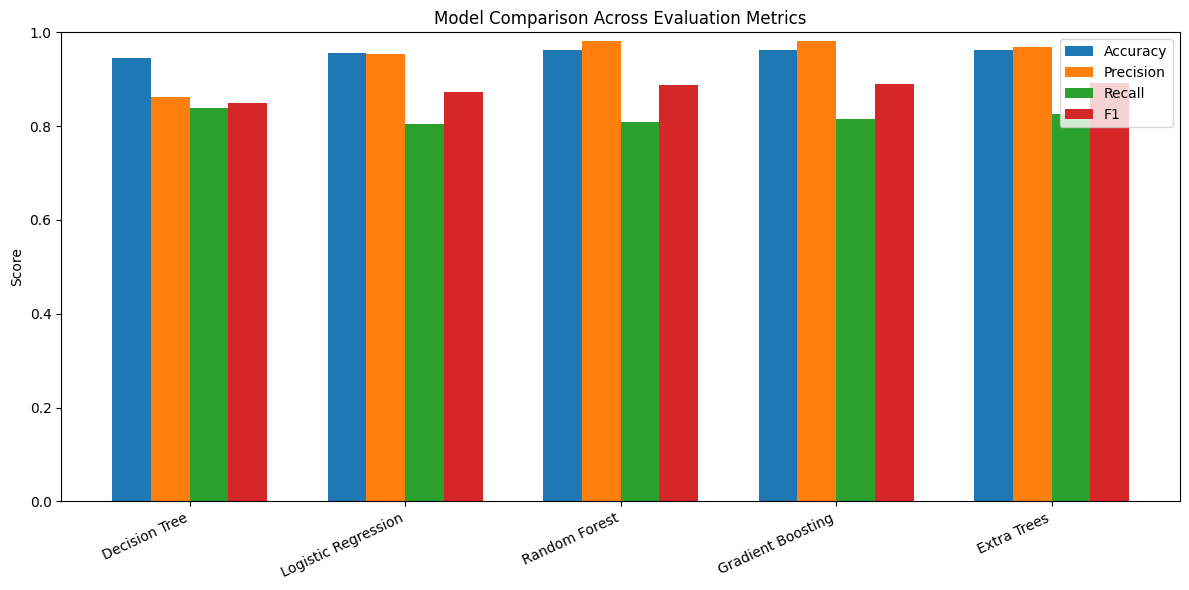

In [20]:
# Plot multiple model comparison metrics

if RUN_MODEL_COMPARISON and not comparison_df.empty:

    plot_metrics = [
        "accuracy_best_threshold",
        "precision_best_threshold",
        "recall_best_threshold",
        "f1_best_threshold",
    ]

    plot_metrics = [m for m in plot_metrics if m in comparison_df.columns]

    plot_df = comparison_df[
        ["model"] + plot_metrics
    ].copy().sort_values("f1_best_threshold", ascending=True)

    plt.figure(figsize=(12, 6))

    x = np.arange(len(plot_df["model"]))
    width = 0.18

    for i, metric in enumerate(plot_metrics):
        plt.bar(
            x + i * width,
            plot_df[metric],
            width,
            label=metric.replace("_best_threshold", "").capitalize()
        )

    plt.xticks(
        x + width * (len(plot_metrics) - 1) / 2,
        plot_df["model"],
        rotation=25,
        ha="right"
    )

    plt.ylabel("Score")
    plt.title("Model Comparison Across Evaluation Metrics")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("No model comparison results to plot.")

## 9. Train Final Random Forest Model

In [17]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=14,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Model training complete")


Model training complete


## 10. Evaluation at Default Threshold

In [18]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_default, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_default, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

print("Classification Report:")
print(classification_report(y_test, y_pred_default, zero_division=0))


Accuracy : 0.9268046441191318
Precision: 0.7583958265405935
Recall   : 0.8946153846153846
F1-score : 0.8208928886536087
Confusion Matrix:
[[10526   741]
 [  274  2326]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     11267
           1       0.76      0.89      0.82      2600

    accuracy                           0.93     13867
   macro avg       0.87      0.91      0.89     13867
weighted avg       0.93      0.93      0.93     13867



## 11. Threshold Tuning

Random Forest outputs anomaly probabilities. Instead of blindly using `0.5`, this cell checks multiple thresholds and selects the one with best F1-score on the test split.


In [19]:
thresholds = np.arange(0.10, 0.91, 0.05)
results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    results.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "predicted_anomaly_rows": int(y_pred_threshold.sum()),
    })

threshold_df = pd.DataFrame(results).sort_values("f1", ascending=False)
threshold_df


,threshold,accuracy,precision,recall,f1,predicted_anomaly_rows
15,0.85,0.961419,0.981352,0.809615,0.887250,2145
14,0.80,0.960770,0.962230,0.823077,0.887231,2224
16,0.90,0.959833,0.991342,0.792692,0.880957,2079
13,0.75,0.957453,0.928754,0.837308,0.880663,2344
12,0.70,0.952333,0.890770,0.850000,0.869907,2481
11,0.65,0.948150,0.859656,0.864615,0.862128,2615
10,0.60,0.942598,0.828478,0.875000,0.851104,2746
9,0.55,0.934737,0.791738,0.884615,0.835604,2905
8,0.50,0.926805,0.758396,0.894615,0.820893,3067
7,0.45,0.913896,0.714199,0.901538,0.797008,3282


## 12. Final Evaluation with Best Threshold

In [20]:
BEST_THRESHOLD = float(threshold_df.iloc[0]["threshold"])
y_pred_best = (y_prob >= BEST_THRESHOLD).astype(int)

print("Best threshold:", BEST_THRESHOLD)
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_best, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_best, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("Classification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))


Best threshold: 0.85
Accuracy : 0.9614191966539266
Precision: 0.9813519813519813
Recall   : 0.8096153846153846
F1-score : 0.8872497365648051
Confusion Matrix:
[[11227    40]
 [  495  2105]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     11267
           1       0.98      0.81      0.89      2600

    accuracy                           0.96     13867
   macro avg       0.97      0.90      0.93     13867
weighted avg       0.96      0.96      0.96     13867



## 13. Per-Video Evaluation

In [21]:
per_video_results = []

for video in sorted(test_df["video_name"].unique()):
    vdf = test_df[test_df["video_name"] == video]

    X_v = vdf[FEATURES]
    y_v = vdf["label"]

    y_prob_v = model.predict_proba(X_v)[:, 1]
    y_pred_v = (y_prob_v >= BEST_THRESHOLD).astype(int)

    per_video_results.append({
        "video_name": video,
        "rows": len(vdf),
        "gt_anomaly_rows": int(y_v.sum()),
        "pred_anomaly_rows": int(y_pred_v.sum()),
        "precision": precision_score(y_v, y_pred_v, zero_division=0),
        "recall": recall_score(y_v, y_pred_v, zero_division=0),
        "f1": f1_score(y_v, y_pred_v, zero_division=0),
    })

per_video_df = pd.DataFrame(per_video_results)
per_video_df


,video_name,rows,gt_anomaly_rows,pred_anomaly_rows,precision,recall,f1
0,umn13,3105,0,9,0.000000,0.000000,0.000000
1,umn14,3477,1275,1131,0.987622,0.876078,0.928512
2,umn15,3326,0,13,0.000000,0.000000,0.000000
3,umn16,3959,1325,992,0.995968,0.745660,0.852827


## 14. Feature Importance

In [22]:
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df


,feature,importance
10,congestion_n,0.209761
5,congestion,0.193589
16,dispersion_n,0.110101
2,density,0.090151
9,density_n,0.065757
8,avg_track_risk,0.065007
13,velocity_n,0.064485
3,avg_velocity,0.061058
15,track_risk_n,0.059009
4,avg_acc,0.016195


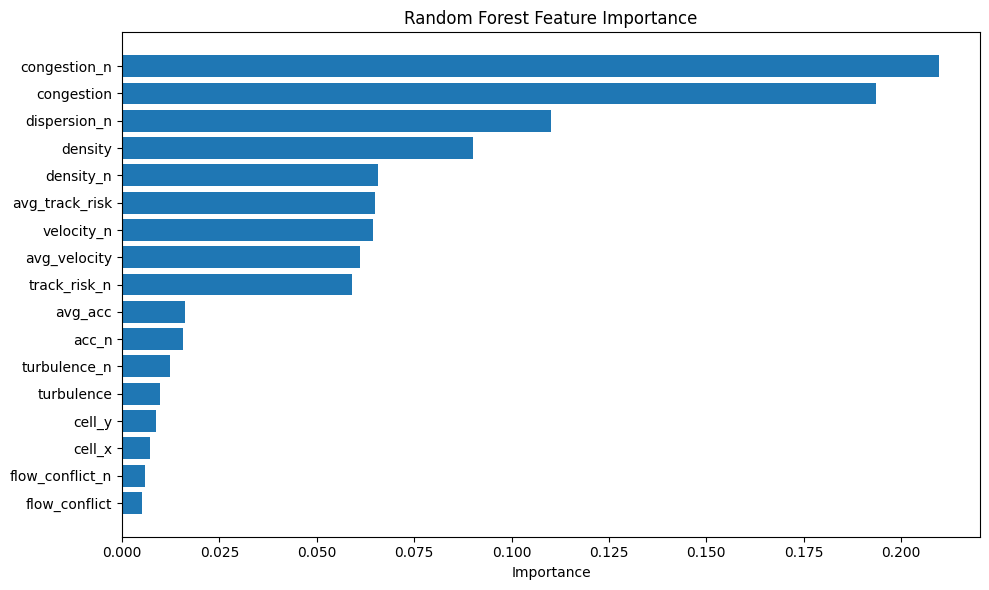

In [23]:
importance_plot_df = importance_df.sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_plot_df["feature"], importance_plot_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 15. Save Model Package

The saved file contains the model, selected feature list, threshold, and experiment settings.


In [24]:
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

model_package = {
    "model": model,
    "features": FEATURES,
    "threshold": BEST_THRESHOLD,
    "test_videos": TEST_VIDEOS,
    "filter_empty_normal_cells": FILTER_EMPTY_NORMAL_CELLS,
    "random_state": RANDOM_STATE,
}

joblib.dump(model_package, MODEL_SAVE_PATH)
print(f"Model package saved to: {MODEL_SAVE_PATH}")


Model package saved to: ..\output\random_forest_anomaly_model.pkl


## 16. Optional: Save Evaluation Tables

In [25]:
EVAL_DIR.mkdir(parents=True, exist_ok=True)

threshold_df.to_csv(EVAL_DIR / "threshold_tuning_results.csv", index=False)
per_video_df.to_csv(EVAL_DIR / "per_video_results.csv", index=False)
importance_df.to_csv(EVAL_DIR / "feature_importance.csv", index=False)

if RUN_MODEL_COMPARISON and not comparison_df.empty:
    comparison_df.to_csv(EVAL_DIR / "model_comparison_results.csv", index=False)

print(f"Evaluation tables saved to: {EVAL_DIR}")


Evaluation tables saved to: output\evaluation


# Severity Level Mapping

Convert anomaly probabilities into operational crowd risk levels:
- Safe
- Warning
- Danger


In [26]:
# Severity thresholds
SAFE_THRESHOLD = 0.35
WARNING_THRESHOLD = 0.70

def get_risk_level(prob):
    if prob < SAFE_THRESHOLD:
        return 'Safe'
    elif prob < WARNING_THRESHOLD:
        return 'Warning'
    else:
        return 'Danger'

# Apply on final predictions
risk_levels = [get_risk_level(p) for p in y_prob]

risk_df = pd.DataFrame({
    'probability': y_prob,
    'risk_level': risk_levels
})

print(risk_df['risk_level'].value_counts())
risk_df.head()


risk_level
Safe       10013
Danger      2481
Warning     1373
Name: count, dtype: int64


,probability,risk_level
0,0.253240,Safe
1,0.054513,Safe
2,0.084161,Safe
3,0.059130,Safe
4,0.118457,Safe


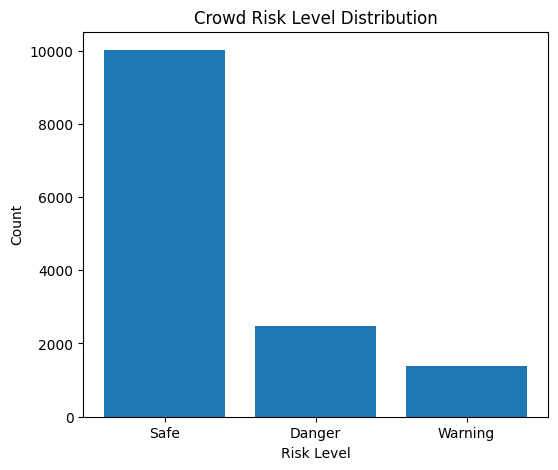

In [27]:
import matplotlib.pyplot as plt

risk_counts = risk_df['risk_level'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(risk_counts.index, risk_counts.values)
plt.title('Crowd Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()


In [28]:
# Per-video severity analysis

for video in sorted(test_df['video_name'].unique()):
    vdf = test_df[test_df['video_name'] == video].copy()

    X_v = vdf[FEATURES]
    probs = model.predict_proba(X_v)[:, 1]
    levels = [get_risk_level(p) for p in probs]

    print('\n' + '=' * 50)
    print(video)
    print('=' * 50)
    print(pd.Series(levels).value_counts())



umn13
Safe       2726
Warning     328
Danger       51
Name: count, dtype: int64

umn14
Safe       1929
Danger     1226
Warning     322
Name: count, dtype: int64

umn15
Safe       2842
Warning     371
Danger      113
Name: count, dtype: int64

umn16
Safe       2516
Danger     1091
Warning     352
Name: count, dtype: int64
